# E11 — Drift Detection Is Harder Than It Looks

> **Enrichment — not examinable.** The official unit content is in `examples/`. This lesson exists to connect what you just learned to how the field works in 2026.

## 📚 Learning Objectives

By completing this notebook, you will:
- Run the **KS test** and **PSI** that lesson 04 taught you, on a real 4½-year production stream instead of two synthetic normals
- Show that the KS **p-value** verdict is driven by how many rows are in your window, not by how different the data is
- Change **one** thing about the windowing — its length, then its reference — and watch the alarm pattern change on identical data
- Demonstrate that KS and PSI, with their standard thresholds, give **opposite** answers about the same month
- Compare three maintenance policies — never retrain, retrain on a drift alarm, retrain on a fixed schedule — on measured F1, and read the result honestly

## 🔗 Where this fits

**Builds on:** Unit 5, lesson 04 `examples/04_drift_detection.ipynb` — that lesson introduced the Kolmogorov–Smirnov test, the Population Stability Index and Jensen–Shannon divergence on two synthetic normal distributions, and told you the three "do not always agree with each other." This notebook makes them disagree, on purpose, on real data, and works out which one you should believe.

**Also builds on:** Unit 5, lesson 02 `examples/02_retraining_pipeline.ipynb`, which listed three retraining triggers — scheduled, performance-based, drift-detected — and said "in practice, you combine all three". Part 6 below actually measures two of them against each other.

**And on:** Course 05 (AIAT 115) — Unit 5, lesson 09 `09_model_monitoring.ipynb`, which trained one classifier on **2016** Montgomery County 911 calls and scored it monthly across 43 months of real history. We reuse that exact setup — same task, same five features, same 2016 reference — so the drift signals below can be compared against a performance curve you have already seen. One caveat if you have downloaded the full 123 MB log: that Course 05 lesson is pinned to the 25,000-row sample so every student sees identical numbers, while this notebook uses whichever copy you have. The shapes stay comparable; the per-month counts will not be.

**Used later in:** Unit 5, lesson 07 (A/B testing and canary deployment) — the decision "is this new model actually better" is the same measurement problem as "did anything actually change", and it fails in the same ways.

## 🌍 Why this matters: a 2026 paper that says your detector is measuring the window

Drift detection is one of the few MLOps practices that everybody adopts and almost nobody evaluates. In February 2026 Brandon Gower-Winter, Misja Groen and Georg Krempl published *The Window Dilemma: Why Concept Drift Detection is Ill-Posed* ([arXiv:2602.06456](https://arxiv.org/abs/2602.06456)). Two claims from its abstract are worth reading slowly:

> "we introduce the Window Dilemma, an observation that perceived drift is a product of windowing and not necessarily the underlying data generating process. Additionally, we highlight that drift detection is ill-posed, primarily because verification of drift events are implausible in practice."

> "Our main finding is that traditional batch learning techniques often perform better than their drift-aware counterparts further bringing into question the purpose of detectors in Stream Classification."

That is not a claim that drift is fake. It is a claim that **the alarm is partly an artefact of the comparison you chose to make** — the width of the window, where you put its edges, and what you compare it against — and that the field has been shipping detectors without checking whether they beat a calendar.

**The named, checkable case we will use.** The **Montgomery County, Maryland 911 dispatch log** is a public record of 663,522 emergency calls from December 2015 to July 2020. The full file is 123 MB, so the repository ships a 25,000-row sample of the same 4½ years and the loader fetches whichever copy your machine has — see 📥 Inputs below, which matters unusually much in this particular lesson. It contains an event nobody disputes: the COVID-19 lockdown. Maryland's statewide stay-at-home order, issued by Governor Larry Hogan, took effect at 8 pm on **30 March 2020**; roads emptied, and the mix of calls changed. You will measure that change in the first cell — the share of dispatches that are traffic incidents falls from about a third to about a fifth — and then spend the rest of the notebook watching standard drift detectors mostly fail to single it out.

**What goes wrong without this lesson.** A team wires a KS test into their monitoring, sets `p < 0.05`, and points it at production traffic. With tens of thousands of rows per window, the test fires most weeks. The team either ignores the alarms — in which case the detector is decoration — or retrains on every alarm, which costs compute, breaks reproducibility, and, as you are about to measure, does not necessarily produce a better model.

## 📥 Inputs & 📤 Outputs

**Input:** the Montgomery County 911 dispatch log, loaded with `load("montgomery_911_calls")`. You never type a path: the loader finds the repository from any working directory, and it works on Google Colab where there is no repository at all.

**Which copy you get — and why that matters more in this lesson than in any other.** The full log is **663,522 dispatches, 123 MB**, too large to commit, so the repository ships a **25,000-row sample**: 1 row in every 27, evenly spread, covering the identical 2015-12-10 → 2020-07-29 window with all 100 call types and all 68 townships. The loader prints which copy it handed you before anything else runs. Read that line.

**Every number printed in this notebook's stored output, and every number quoted in the markdown below, came from the full file.** On the sample your numbers will differ — not slightly, but in their *verdicts*:

| what the notebook measures | full file (663,522 rows, ≈12,000 calls/month) | bundled sample (25,000 rows, ≈450 calls/month) |
|---|---|---|
| KS alarms across 43 monthly windows | **26 of 43 (60%)** | **0 of 43 (0%)** |
| April 2020's rank by KS statistic | 3rd of 43 | 5th of 43 |
| Experiment 2 — fixed vs trailing reference | 57% vs 45%, disagreeing on 19 of 42 windows | 0% vs 0%, disagreeing on 0 of 42 |
| months with PSI above 0.10, at any bin count | 0 | 0 |
| retrains bought by the drift trigger (Part 6) | 27 | 0 |

Same county, same 4½ years, same feature, same test, same threshold. One copy pages an operator most months; the other never pages anyone at all — including straight through a lockdown that *both* copies show plainly in the very first chart. That is this notebook's thesis arriving before the notebook has finished arguing it: **the alarm is largely a function of how many rows you fed it.** Whichever copy you have, trust the numbers your run prints over the prose around them. `Course 04/datasets/DATA.md` says how to fetch the full file.

**Outputs:** a monthly trend of the real 2020 shift; a monthly KS-test drift table with alarm rates; the same test at three window lengths and against two different reference windows; a p-value-versus-sample-size curve on a month where nothing happened; PSI at three binning choices; the measured relationship between drift signal and actual model degradation; and a head-to-head of three maintenance policies with their retrain counts.

**Runtime:** about 30 seconds on a CPU with the full file, a few seconds on the sample. The heaviest part is Part 6, which fits roughly three dozen small random forests.

## Part 1: The Stream, and the One Event We Know Happened

Before testing a detector, establish ground truth — which is precisely what the Window Dilemma paper says you normally cannot do ("verification of drift events are implausible in practice"). This dataset is unusual in that we *can*: a global, dated, externally documented event sits inside it.

We use the same task Course 05 used: **is this dispatch a traffic incident?**, predicted from the hour, day of week, month and location. Reference period: **all of 2016**. Everything from 2017 onward is "production".

In [1]:
# WHAT: load the real 911 dispatch log and measure, month by month, the thing we already know
#       changed — the share of calls that are traffic incidents.
# WHY:  a drift detector is only assessable against an event you can independently confirm.
#       This cell establishes that event before any detector is allowed an opinion.
import time
import numpy as np
import pandas as pd
from scipy import stats as sp_stats
import matplotlib.pyplot as plt          # the notebook kernel renders inline; no window is opened

NOTEBOOK_START = time.perf_counter()

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/montgomery_911_calls.csv' only resolves
#       when the kernel's working directory happens to be this notebook's folder. This does
#       not care - and the 123 MB call log is not committed, so on a fresh clone or on Colab
#       the loader hands you the 25,000-row sample instead and says so out loud.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load, is_sample
# -------------------------------------------------------------------------------------
calls = load("montgomery_911_calls",
             usecols=["lat", "lng", "title", "timeStamp"], parse_dates=["timeStamp"])
ON_SAMPLE = is_sample("montgomery_911_calls")
calls["service"] = calls["title"].str.split(":").str[0]      # EMS / Traffic / Fire
calls["is_traffic"] = (calls["service"] == "Traffic").astype(int)
calls["hour"] = calls["timeStamp"].dt.hour
calls["dow"] = calls["timeStamp"].dt.dayofweek
calls["month_num"] = calls["timeStamp"].dt.month
calls = calls.sort_values("timeStamp").reset_index(drop=True)
calls["period"] = calls["timeStamp"].dt.to_period("M")

FEATURES = ["hour", "dow", "month_num", "lat", "lng"]
REFERENCE = calls[(calls["timeStamp"] >= "2016-01-01") & (calls["timeStamp"] < "2017-01-01")]
STREAM = calls[calls["timeStamp"] >= "2017-01-01"]

print(f"{len(calls):,} dispatches from {calls['timeStamp'].min():%Y-%m-%d} "
      f"to {calls['timeStamp'].max():%Y-%m-%d}"
      f"{'   [BUNDLED SAMPLE - see Inputs above]' if ON_SAMPLE else ''}")
print(f"reference window (2016)     : {len(REFERENCE):,} calls")
print(f"production stream (2017 on) : {len(STREAM):,} calls, "
      f"{STREAM['period'].nunique()} complete-ish months\n")

monthly = STREAM.groupby("period").agg(calls=("is_traffic", "size"),
                                       traffic_share=("is_traffic", "mean"))
pre_covid = STREAM[STREAM["timeStamp"] < "2020-01-01"]["is_traffic"].mean()
print(f"Traffic share, 2017-2019 average : {pre_covid:.1%}")
print("Traffic share, 2020 month by month:")
for period, row in monthly.loc["2020-01":].iterrows():
    delta = (row["traffic_share"] - pre_covid) * 100      # percentage points, not a fraction
    flag = "   <-- stay-at-home order took effect 30 March 2020" if str(period) == "2020-04" else ""
    print(f"  {period}  {row['calls']:6,.0f} calls   traffic {row['traffic_share']:.1%}  "
          f"({delta:+.1f} pp vs 2017-2019){flag}")

montgomery_911_calls: full file, 663,522 rows.


663,522 dispatches from 2015-12-10 to 2020-07-29
reference window (2016)     : 142,360 calls
production stream (2017 on) : 513,246 calls, 43 complete-ish months

Traffic share, 2017-2019 average : 35.5%
Traffic share, 2020 month by month:
  2020-01  12,208 calls   traffic 33.9%  (-1.6 pp vs 2017-2019)
  2020-02  11,043 calls   traffic 31.2%  (-4.3 pp vs 2017-2019)
  2020-03   9,920 calls   traffic 24.9%  (-10.6 pp vs 2017-2019)
  2020-04   8,243 calls   traffic 20.8%  (-14.6 pp vs 2017-2019)   <-- stay-at-home order took effect 30 March 2020
  2020-05   9,042 calls   traffic 23.3%  (-12.2 pp vs 2017-2019)
  2020-06  11,541 calls   traffic 29.2%  (-6.3 pp vs 2017-2019)
  2020-07  10,261 calls   traffic 29.2%  (-6.3 pp vs 2017-2019)


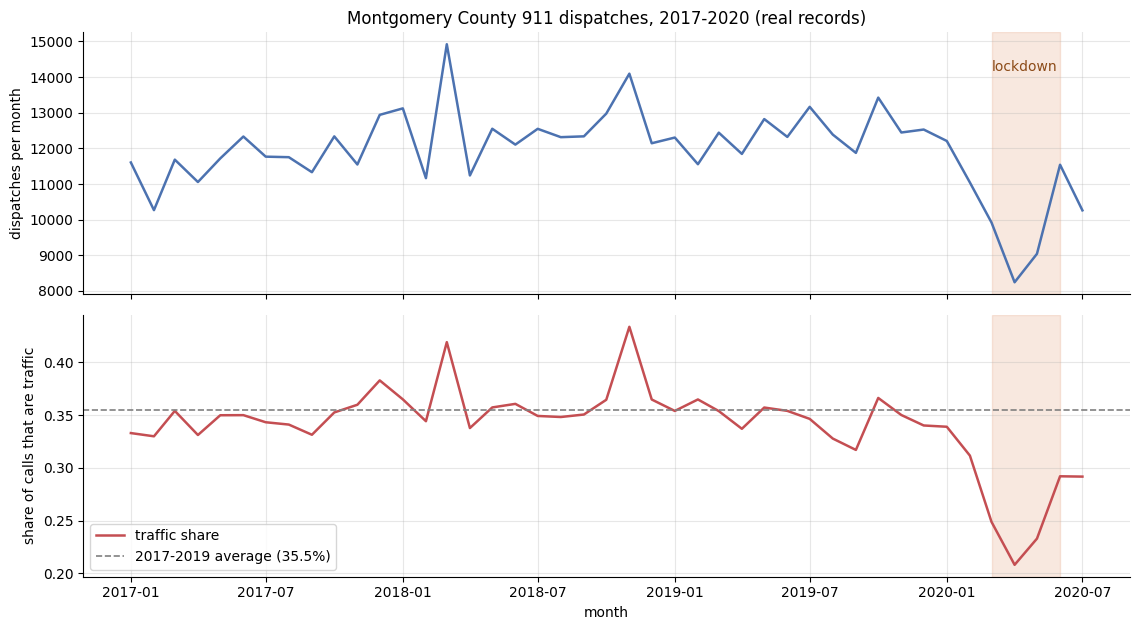

The shaded band is the only event in this stream that we can verify from outside the data.
Note what it looks like: a drop, then most of a recovery, inside four months.


In [2]:
# WHAT: plot call volume and traffic share across the whole stream, with 2020 marked.
# WHY:  every detector below is trying to rediscover what this chart shows in one glance.
#       Keep it on screen: it is the only ground truth we have.
fig, axes = plt.subplots(2, 1, figsize=(11.5, 6.4), sharex=True)
x = monthly.index.to_timestamp()

axes[0].plot(x, monthly["calls"], color="#4C72B0", lw=1.8)
axes[0].set_ylabel("dispatches per month")
axes[0].set_title("Montgomery County 911 dispatches, 2017-2020 (real records)")

axes[1].plot(x, monthly["traffic_share"], color="#C44E52", lw=1.8, label="traffic share")
axes[1].axhline(pre_covid, ls="--", color="gray", lw=1.2,
                label=f"2017-2019 average ({pre_covid:.1%})")
axes[1].set_ylabel("share of calls that are traffic")
axes[1].set_xlabel("month")
axes[1].legend(loc="lower left")

for ax in axes:
    ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-06-01"), color="#DD8452", alpha=0.18)
    ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].annotate("lockdown", xy=(pd.Timestamp("2020-04-15"), monthly["calls"].max() * 0.95),
                 ha="center", fontsize=10, color="#8C4B18")
plt.tight_layout()
plt.show()

print("The shaded band is the only event in this stream that we can verify from outside the data.")
print("Note what it looks like: a drop, then most of a recovery, inside four months.")

## Part 2: The Standard Detector, Run Honestly

Lesson 04 gave you the recipe: take a numerical feature, compare the production window against the reference window with a two-sample KS test, and alarm when `p < 0.05`. We will watch the **hour of day** — a genuine behavioural signal, and the one you would expect a lockdown to move.

Two numbers come out of `ks_2samp`, and the difference between them is the whole of Part 2 and Part 3:

- the **statistic**: the largest gap between the two cumulative distributions. This is an **effect size** — "how different", on a 0-to-1 scale.
- the **p-value**: the probability of seeing a gap that large if the two windows came from the same distribution. This is a statement about **evidence**, and evidence accumulates with sample size.

A monitoring rule built on the p-value is asking "am I sure they differ?" A monitoring rule built on the statistic is asking "do they differ enough to matter?" Production teams almost always write the first rule and believe they wrote the second.

In [3]:
# WHAT: run the KS test on hour-of-day for every production month against the 2016 reference,
#       and report both outputs of the test side by side.
# WHY:  to see how often a textbook detector fires on a real stream, and whether the months it
#       ranks highest are the months we know something happened.
def monthly_ks(feature, reference_values, stream_df, min_rows=200):
    """KS statistic and p-value for each production month against a fixed reference sample."""
    rows = []
    for period, group in stream_df.groupby("period"):
        if len(group) < min_rows:
            continue
        result = sp_stats.ks_2samp(reference_values, group[feature].values)
        rows.append({"period": str(period), "n": len(group),
                     "ks_stat": result.statistic, "p_value": result.pvalue,
                     "traffic_share": group["is_traffic"].mean()})
    return pd.DataFrame(rows)

drift = monthly_ks("hour", REFERENCE["hour"].values, STREAM)
drift["alarm"] = drift["p_value"] < 0.05

alarm_rate = drift["alarm"].mean()
print(f"KS test on hour-of-day, 2016 reference, {len(drift)} monthly windows")
print(f"  months with p < 0.05          : {drift['alarm'].sum()} of {len(drift)}  ({alarm_rate:.0%})")
print(f"  median KS statistic           : {drift['ks_stat'].median():.4f}  "
      f"(largest CDF gap, on a 0-1 scale)")
print(f"  largest KS statistic          : {drift['ks_stat'].max():.4f}\n")

print("The eight months this detector considers most drifted:")
top = drift.sort_values("ks_stat", ascending=False).head(8)
print(top[["period", "n", "ks_stat", "p_value", "traffic_share"]]
      .to_string(index=False, float_format=lambda v: f"{v:.6g}"))

covid = drift.set_index("period").loc["2020-04"]
rank = int((drift["ks_stat"] > covid["ks_stat"]).sum()) + 1
print(f"\nApril 2020 — the month with the verified event — ranks {rank} of {len(drift)} "
      f"by KS statistic.")
print(f"Its statistic is {covid['ks_stat']:.4f}: the hour-of-day distribution moved by "
      f"{covid['ks_stat']:.1%} at its widest point.")

KS test on hour-of-day, 2016 reference, 43 monthly windows
  months with p < 0.05          : 26 of 43  (60%)
  median KS statistic           : 0.0149  (largest CDF gap, on a 0-1 scale)
  largest KS statistic          : 0.0426

The eight months this detector considers most drifted:
 period     n   ks_stat     p_value  traffic_share
2020-06 11541 0.0425951 2.86915e-17       0.292089
2018-03 14923 0.0400641 2.82828e-19       0.419219
2020-04  8243 0.0321891 1.89521e-07       0.208177
2019-07 13166 0.0311339 1.39239e-10       0.346499
2018-01 13123 0.0311118 1.54328e-10       0.365008
2017-06 12333  0.028925 1.10437e-08       0.350036
2017-03 11684 0.0263223 6.22544e-07       0.354074
2019-02 11556 0.0257721 1.33875e-06       0.364919

April 2020 — the month with the verified event — ranks 3 of 43 by KS statistic.
Its statistic is 0.0322: the hour-of-day distribution moved by 3.2% at its widest point.


### The comparative experiment

**Baseline:** monthly windows (about 30 days), reference = all of 2016.
**Change exactly one thing, twice:**
1. the **window length** — 7 days, 30 days, 90 days — keeping the reference fixed;
2. the **reference** — compare each window against the *previous window of the same length* instead of against 2016, keeping the length fixed.

Neither change touches a single row of data. If the verdicts move, the verdicts were partly about the windowing.

In [4]:
# WHAT: rerun the identical test at three window lengths, then rerun it with a trailing
#       reference instead of a fixed one, and compare the alarm patterns.
# WHY:  this is the Window Dilemma made concrete. Same stream, same feature, same test,
#       same threshold — only the comparison geometry changes.
def sliding_windows(df, days, start="2017-01-01", min_rows=50):
    """Consecutive non-overlapping windows of `days` days over the production stream."""
    edge, last = pd.Timestamp(start), df["timeStamp"].max()
    out = []
    while edge + pd.Timedelta(days=days) <= last:
        w = df[(df["timeStamp"] >= edge) & (df["timeStamp"] < edge + pd.Timedelta(days=days))]
        if len(w) >= min_rows:
            out.append((edge, w["hour"].values))
        edge += pd.Timedelta(days=days)
    return out

print("EXPERIMENT 1 — change the window length, keep the 2016 reference\n")
print(f"{'window':>10} {'windows':>9} {'median n':>10} {'alarm rate':>12} {'median KS':>11} {'max KS':>9}")
length_results = {}
for days in (7, 30, 90):
    ws = sliding_windows(STREAM, days)
    res = [sp_stats.ks_2samp(REFERENCE["hour"].values, v) for _, v in ws]
    stat = np.array([r.statistic for r in res])
    pval = np.array([r.pvalue for r in res])
    n = np.array([len(v) for _, v in ws])
    length_results[days] = (stat, pval)
    print(f"{days:>8}d {len(ws):>9} {int(np.median(n)):>10,} {(pval < 0.05).mean():>11.0%} "
          f"{np.median(stat):>11.4f} {stat.max():>9.4f}")

print("\nEXPERIMENT 2 — keep 30-day windows, change only what they are compared against\n")
ws30 = sliding_windows(STREAM, 30)
fixed_p = np.array([sp_stats.ks_2samp(REFERENCE["hour"].values, v).pvalue for _, v in ws30])
trailing_p = np.array([np.nan] + [sp_stats.ks_2samp(ws30[i - 1][1], ws30[i][1]).pvalue
                                  for i in range(1, len(ws30))])

fixed_alarm = fixed_p[1:] < 0.05
trailing_alarm = trailing_p[1:] < 0.05
print(f"  reference = all of 2016            : {fixed_alarm.mean():.0%} of windows alarm")
print(f"  reference = the previous 30 days   : {trailing_alarm.mean():.0%} of windows alarm")
print(f"  the two rules agree on             : {(fixed_alarm == trailing_alarm).mean():.0%} "
      f"of windows")
print(f"  windows where they disagree        : {int((fixed_alarm != trailing_alarm).sum())} "
      f"of {len(fixed_alarm)}")

EXPERIMENT 1 — change the window length, keep the 2016 reference

    window   windows   median n   alarm rate   median KS    max KS


       7d       186      2,755         37%      0.0218    0.1153


      30d        43     11,904         58%      0.0156    0.0435


      90d        14     35,991         50%      0.0091    0.0255

EXPERIMENT 2 — keep 30-day windows, change only what they are compared against



  reference = all of 2016            : 57% of windows alarm
  reference = the previous 30 days   : 45% of windows alarm
  the two rules agree on             : 55% of windows
  windows where they disagree        : 19 of 42


### Conclusion the printed numbers support

*The figures in this section are the **full file's**. If your first cell reported the bundled sample, every alarm rate here is 0% instead — the 📥 Inputs table lists the substitutions, and the closing paragraph of this section says what survives either way.*

**The detector is not random — it has real signal in it.** April 2020, the one month with an externally verified event, comes **third of 43** by KS statistic. Something in this test knows about the lockdown.

**And it is unusable as an alarm.** It fires in **26 of 43 months (60%)**. The month it ranks *second* is **March 2018** — an ordinary month, no recorded event, hour-of-day statistic **0.04006** against April 2020's **0.0322**. An operator paged by this rule is paged most months, and on the one occasion the page is real it looks exactly like the twenty-five that were not (26 months alarm; exactly one of them is the event).

**Experiment 1 — the window length changes the answer, and not in the direction you would guess.** 7-day windows alarm on 37% of windows, 30-day on 58%, 90-day on 50%. Meanwhile the median effect size falls monotonically: 0.0218 → 0.0156 → 0.0091. Two forces pull against each other. More rows per window give the test more statistical power; longer windows average over more seasonal variation and so leave less difference to find. The alarm rate is the product of the two, which is why it is not monotone — and why "just choose a sensible window" has no sensible answer.

**Experiment 2 — the reference window changes the answer too.** Holding the length fixed at 30 days and changing only what each window is compared against — all of 2016, versus the immediately preceding 30 days — moves the alarm rate from **57% to 45%**, and the two rules disagree on **19 of 42** windows. Same rows, same test, same threshold, opposite conclusions on nearly half the stream.

That is the Window Dilemma, measured: a large part of what these detectors report is the geometry of the comparison you chose, not the behaviour of Montgomery County. Part 3 isolates where most of the sensitivity comes from.

**And on the sample, the same detector fails in the mirror-image way.** With ≈450 calls per window instead of ≈12,000, the KS test fires in **0 of 43 months** — it sleeps through the lockdown it ranks 5th, and Experiment 2's two rules agree on 42 of 42 windows because neither ever fires. False alarms most months on one copy, silence on a verified event on the other, from one test at one threshold. The threshold was never measuring the world; it was measuring `n`.

## Part 3: Why the P-Value Moves — It Is Counting Rows

Here is the mechanism, and it is not subtle once you see it. The KS statistic is a **distance**; it does not care how many rows produced it. The p-value asks whether a distance that large could be luck, and luck gets less plausible the more rows you have. Roughly, the KS test's critical distance shrinks like `1/√n`.

So on a stream delivering 12,000 rows a month — which the full file does — a **2 % gap** between two distributions is overwhelming evidence of a real difference, and a 2 % gap is also, operationally, nothing. Run the same month at 450 rows, as the bundled sample does, and the identical 2 % gap is no evidence of anything.

One honest complication you will see in the table: at very small *n* the KS **statistic** is biased *upward*, because with 100 points the largest gap between two step functions is mostly noise. So the effect-size column falls at first and then settles. What matters is where it settles, and how far the p-value keeps travelling after it does.

To show this cleanly we need a month where nothing happened. **January 2019** will do: no event, no anomaly, ordinary winter month. We will subsample it to different sizes and re-run the identical test. This is the one place in this notebook where random sampling appears, and it is the point of the experiment rather than a substitute for data. The ladder of sizes stops at whatever this month actually holds — about 12,300 calls in the full file, about 460 in the bundled sample — so on the sample the curve covers only the small-*n* end, and the cell says so in its own output.

In [5]:
# WHAT: take one ordinary month, draw random subsamples of increasing size, and run the same
#       KS test on each. Repeat 30 times per size so the medians are stable.
# WHY:  the data is fixed. Only n changes. Whatever the p-value does here, it is doing to n.
QUIET = "2019-01"
quiet_hours = STREAM[STREAM["period"] == QUIET]["hour"].values
rng = np.random.default_rng(7)          # sampling IS the experiment here, not a stand-in for data

# WHAT: keep only the ladder steps this month can actually supply, then always finish
#       at the whole month.
# WHY:  on the full file this month holds ~12,000 calls; on the bundled sample it holds a
#       few hundred. Asking for 10,000 of 463 would silently re-test the same window three
#       times over and print a table of duplicate rows.
LADDER = [100, 250, 500, 1000, 2500, 5000, 10000]
sizes = [n for n in LADDER if n < len(quiet_hours)] + [len(quiet_hours)]
rows = []
for n in sizes:
    stats_n, pvals_n = [], []
    for _ in range(30):
        sample = rng.choice(quiet_hours, size=min(n, len(quiet_hours)), replace=False)
        result = sp_stats.ks_2samp(REFERENCE["hour"].values, sample)
        stats_n.append(result.statistic)
        pvals_n.append(result.pvalue)
    rows.append({"n": min(n, len(quiet_hours)),
                 "median KS stat": float(np.median(stats_n)),
                 "median p": float(np.median(pvals_n)),
                 "alarm rate": float(np.mean(np.array(pvals_n) < 0.05))})
size_study = pd.DataFrame(rows)

print(f"Same month ({QUIET}, an ordinary month with no known event), same reference, same test.")
print("Only the number of rows in the window changes.\n")
print(size_study.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

# Pick the three rows by POSITION, not by hard-coded n: the ladder above is as long as this
# copy of the data allows, so 250 and 2500 are not guaranteed to be in it.
small, mid, full = size_study.iloc[0], size_study.iloc[len(size_study) // 2], size_study.iloc[-1]

def verdict(p):
    """What a `p < 0.05` monitoring rule would report for a window with this p-value."""
    return "DRIFT DETECTED" if p < 0.05 else "no drift"

print("\nWhat a p < 0.05 alarm would have said, at three window sizes:")
for row in (small, mid, full):
    print(f"    n = {row['n']:>6,.0f}   {verdict(row['median p']):>14}   "
          f"(median p = {row['median p']:.3g}, alarm rate {row['alarm rate']:.0%})")
print(f"\nMeanwhile the effect size settles at about {full['median KS stat']:.3f} — the two "
      f"cumulative distributions")
print(f"differ by {full['median KS stat']:.1%} at their widest point, which is a difference no "
      f"operator would act on.")

ratio = small["median p"] / full["median p"]
if ratio >= 1:
    print(f"The p-value fell by a factor of {ratio:,.0f} over the same range.")
    print("\nNothing changed about the world. The monitoring window just got a month's worth "
          "of traffic.")
else:
    # The KS test's 5% critical distance shrinks like 1.36/sqrt(n), so invert it to get the
    # window size at which a gap this small would finally count as evidence.
    need = int((1.36 / full["median KS stat"]) ** 2)
    print(f"The p-value did not fall here — it ROSE by a factor of {1 / ratio:,.1f}. A gap of "
          f"{full['median KS stat']:.1%} only becomes")
    print(f"resolvable at roughly n = {need:,} rows, and this copy of the stream supplies "
          f"{full['n']:,.0f}.")
    print("\nSame mechanism, opposite face: the alarm is tracking the row count, and here the "
          "row count is small.")

Same month (2019-01, an ordinary month with no known event), same reference, same test.
Only the number of rows in the window changes.

    n  median KS stat  median p  alarm rate
  100         0.08304    0.4707     0.03333
  250         0.04928    0.5628     0.03333
  500         0.04135    0.3525         0.1
 1000         0.03254    0.2385         0.2
 2500         0.02605   0.06993      0.4333
 5000         0.02204   0.01803      0.8667
10000         0.02091 0.0005619           1
12304          0.0209 9.956e-05           1

What a p < 0.05 alarm would have said, at three window sizes:
    n =    100         no drift   (median p = 0.471, alarm rate 3%)
    n =  2,500         no drift   (median p = 0.0699, alarm rate 43%)
    n = 12,304   DRIFT DETECTED   (median p = 9.96e-05, alarm rate 100%)

Meanwhile the effect size settles at about 0.021 — the two cumulative distributions
differ by 2.1% at their widest point, which is a difference no operator would act on.
The p-value fell by a f

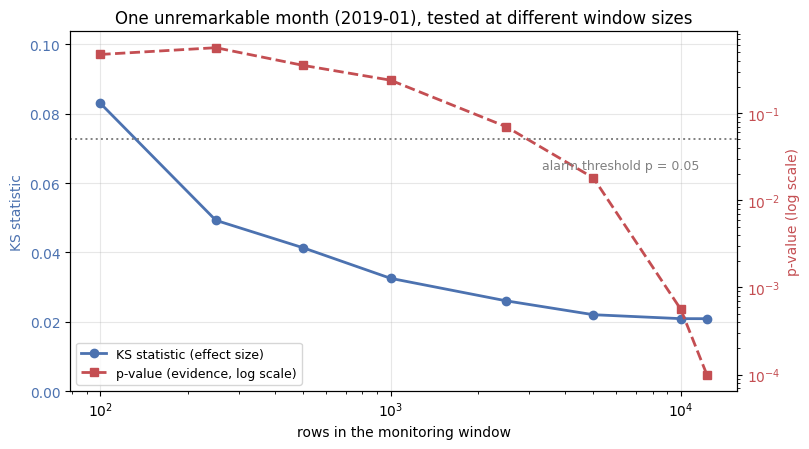

In [6]:
# WHAT: plot the two curves from the table above on one figure, on a log x-axis.
# WHY:  one line settles and the other keeps falling through the alarm threshold. That picture
#       is the argument for putting an effect size, not a p-value, on a monitoring dashboard.
fig, ax1 = plt.subplots(figsize=(8.2, 4.6))
ax1.semilogx(size_study["n"], size_study["median KS stat"], "o-", color="#4C72B0", lw=2,
             label="KS statistic (effect size)")
ax1.set_xlabel("rows in the monitoring window")
ax1.set_ylabel("KS statistic", color="#4C72B0")
ax1.set_ylim(0, max(size_study["median KS stat"]) * 1.25)
ax1.tick_params(axis="y", labelcolor="#4C72B0")

ax2 = ax1.twinx()
ax2.loglog(size_study["n"], size_study["median p"], "s--", color="#C44E52", lw=2,
           label="p-value (evidence, log scale)")
ax2.axhline(0.05, color="gray", ls=":", lw=1.4)
ax2.text(size_study["n"].max(), 0.03, "alarm threshold p = 0.05  ", fontsize=9, color="gray",
         ha="right", va="top")
ax2.set_ylabel("p-value (log scale)", color="#C44E52")
ax2.tick_params(axis="y", labelcolor="#C44E52")

ax1.set_title(f"One unremarkable month ({QUIET}), tested at different window sizes")
lines = ax1.get_lines() + ax2.get_lines()[:1]
ax1.legend(lines, [l.get_label() for l in lines], loc="lower left", fontsize=9)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 💬 Discuss

1. Part 3 shows a fixed threshold on a p-value behaving as a row counter. Propose a monitoring rule for this stream that would **not** have this defect, state the number you would put on the dashboard, and say how you would choose its threshold — remembering that you cannot use April 2020 to pick it, because in March 2020 you did not know April was coming.
2. Experiment 2 compared each window against the previous one instead of against 2016, and the two rules disagreed on a substantial fraction of windows. Which of the two would you rather run against a stream with strong seasonality, and what real change would the one you rejected be **blind** to?
3. The Window Dilemma paper argues detection is ill-posed because "verification of drift events are implausible in practice". This notebook cheats: it has a verified event. Describe a system you have worked on or can imagine, and say honestly whether you could ever have produced a labelled list of its true drift events — and if not, what you would have validated a detector against instead.

## Part 4: PSI Has the Opposite Problem

The Population Stability Index is the other tool lesson 04 taught, and it is standard in credit risk. It compares two binned distributions:

`PSI = Σ (p_new − p_ref) · ln(p_new / p_ref)`

with the conventional reading: **< 0.1** stable, **0.1 – 0.25** moderate shift, **> 0.25** major shift. Unlike a p-value it is an effect size, so it does not inflate with sample size — Part 3's failure mode cannot happen to it.

It has a different dependency, and it is one nobody writes down in the runbook: **PSI is a function of the bins you chose.** Change the binning and you change the number. Below we compute PSI for every production month at three bin counts, and check what its standard thresholds say about the one month we know was different.

In [7]:
# WHAT: compute PSI for every production month at three different bin counts, and compare its
#       verdicts against the KS test's verdicts on exactly the same windows.
# WHY:  two textbook detectors, one feature, one stream. If they disagree, at least one runbook
#       in the world is wrong, and you should find out which before you write yours.
def psi(reference_values, new_values, bins):
    """Population Stability Index over `bins` equal-width bins spanning both samples."""
    edges = np.histogram_bin_edges(np.concatenate([reference_values, new_values]), bins=bins)
    ref_counts, _ = np.histogram(reference_values, edges)
    new_counts, _ = np.histogram(new_values, edges)
    p_ref = np.clip(ref_counts / ref_counts.sum(), 1e-6, None)      # clip: ln(0) is not a number
    p_new = np.clip(new_counts / new_counts.sum(), 1e-6, None)
    return float(np.sum((p_new - p_ref) * np.log(p_new / p_ref)))

ref_hours = REFERENCE["hour"].values
for bins in (5, 10, 20):
    drift[f"psi_{bins}"] = [psi(ref_hours, STREAM[STREAM["period"] == p]["hour"].values, bins)
                            for p in drift["period"]]

print("PSI on hour-of-day, all 43 production months, at three binning choices")
print(f"{'bins':>6} {'median PSI':>12} {'max PSI':>10} {'worst month':>13} "
      f"{'months > 0.10':>15} {'months > 0.25':>15}")
for bins in (5, 10, 20):
    col = drift[f"psi_{bins}"]
    print(f"{bins:>6} {col.median():>12.4f} {col.max():>10.4f} "
          f"{drift.loc[col.idxmax(), 'period']:>13} "
          f"{int((col > 0.10).sum()):>15} {int((col > 0.25).sum()):>15}")

print(f"\nChanging the bin count alone moves April 2020's PSI from "
      f"{drift.set_index('period').loc['2020-04', 'psi_5']:.4f} (5 bins) to "
      f"{drift.set_index('period').loc['2020-04', 'psi_20']:.4f} (20 bins) — "
      f"a factor of {drift.set_index('period').loc['2020-04', 'psi_20'] / drift.set_index('period').loc['2020-04', 'psi_5']:.1f}.")

agree = ((drift["p_value"] < 0.05) == (drift["psi_10"] > 0.10)).mean()
print(f"\nVERDICT COMPARISON on the same 43 months, same feature:")
print(f"  KS  (p < 0.05)  says DRIFT in {(drift['p_value'] < 0.05).sum():>2} months")
print(f"  PSI (> 0.10)    says DRIFT in {int((drift['psi_10'] > 0.10).sum()):>2} months")
print(f"  the two agree on {agree:.0%} of months — including on April 2020, where KS says "
      f"{'DRIFT' if drift.set_index('period').loc['2020-04', 'p_value'] < 0.05 else 'no drift'} "
      f"and PSI says "
      f"{'DRIFT' if drift.set_index('period').loc['2020-04', 'psi_10'] > 0.10 else 'no drift'}.")

PSI on hour-of-day, all 43 production months, at three binning choices
  bins   median PSI    max PSI   worst month   months > 0.10   months > 0.25
     5       0.0018     0.0112       2020-06               0               0
    10       0.0031     0.0249       2020-06               0               0
    20       0.0050     0.0274       2020-06               0               0

Changing the bin count alone moves April 2020's PSI from 0.0107 (5 bins) to 0.0187 (20 bins) — a factor of 1.8.

VERDICT COMPARISON on the same 43 months, same feature:
  KS  (p < 0.05)  says DRIFT in 26 months
  PSI (> 0.10)    says DRIFT in  0 months
  the two agree on 40% of months — including on April 2020, where KS says DRIFT and PSI says no drift.


## Part 5: Does the Alarm Mean Harm?

Every detector so far has been watching an **input**. Nobody deploys a monitor to detect changes in inputs; they deploy it to be warned that the **model** is getting worse. Those are different events, and lesson 04's own vocabulary says so: data drift is a change in P(X), concept drift is a change in P(Y|X), and only the second is guaranteed to hurt.

So: freeze the 2016 model, score every production month, and ask whether the drift signal has any relationship to the damage.

In [8]:
# WHAT: train once on 2016, freeze the model, score all 43 production months, then correlate
#       the monthly F1 against the covariate drift signal and against the label shift.
# WHY:  a monitor earns its place only if its alarm predicts harm. This measures whether it does.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

N_TREES, MAX_DEPTH = 25, 12      # small on purpose: this notebook fits ~35 forests in Part 6

def fit_model(frame):
    """One small random forest on the traffic-vs-not task, trained on whatever frame you pass."""
    model = RandomForestClassifier(n_estimators=N_TREES, max_depth=MAX_DEPTH,
                                   random_state=42, n_jobs=-1)
    model.fit(frame[FEATURES], frame["is_traffic"])
    return model

frozen = fit_model(REFERENCE)
drift["f1"] = [f1_score(STREAM[STREAM["period"] == p]["is_traffic"],
                        frozen.predict(STREAM[STREAM["period"] == p][FEATURES]))
               for p in drift["period"]]
drift["label_shift"] = (drift["traffic_share"] - REFERENCE["is_traffic"].mean()).abs()

pre = drift[drift["period"] < "2020-03"]["f1"]
print(f"Model trained once on {len(REFERENCE):,} calls from 2016, then never touched.")
print(f"  F1 on the traffic class, 2017-Feb 2020 : mean {pre.mean():.3f}")
print(f"  F1 in April 2020                       : "
      f"{drift.set_index('period').loc['2020-04', 'f1']:.3f}")
print(f"  worst month                            : {drift.loc[drift['f1'].idxmin(), 'period']} "
      f"({drift['f1'].min():.3f})\n")

for signal, label in (("ks_stat", "KS statistic on hour (a covariate)"),
                      ("psi_10", "PSI on hour, 10 bins (a covariate)"),
                      ("label_shift", "shift in P(traffic), i.e. the LABEL")):
    r = np.corrcoef(drift[signal], drift["f1"])[0, 1]
    print(f"  correlation with monthly F1: {r:+.3f}   {label}")

r_psi = np.corrcoef(drift["psi_10"], drift["f1"])[0, 1]
r_ks = np.corrcoef(drift["ks_stat"], drift["f1"])[0, 1]
r_label = np.corrcoef(drift["label_shift"], drift["f1"])[0, 1]
print("\nRead the three correlations as a set, and notice what they do NOT say.")
print(f"They do not say covariate monitoring is useless: PSI on this one input ranks the months")
print(f"almost as well as the label shift itself ({r_psi:+.3f} against {r_label:+.3f}), and far")
print(f"better than the KS statistic the alarm is actually built on ({r_ks:+.3f}).")
print(f"\nWhat they say is that the WARNING never arrived. PSI's standard 0.10 threshold — the")
print(f"number written in every runbook — was not crossed in any of the {len(drift)} months, "
      f"including the")
print(f"month the frozen model lost {pre.mean() - drift.set_index('period').loc['2020-04', 'f1']:.3f} "
      f"of its F1. The statistic was informative.")
print("The constant sitting next to it was wrong for this stream, and nobody would have known.")

Model trained once on 142,360 calls from 2016, then never touched.
  F1 on the traffic class, 2017-Feb 2020 : mean 0.335
  F1 in April 2020                       : 0.258
  worst month                            : 2020-05 (0.246)

  correlation with monthly F1: -0.322   KS statistic on hour (a covariate)
  correlation with monthly F1: -0.612   PSI on hour, 10 bins (a covariate)
  correlation with monthly F1: -0.718   shift in P(traffic), i.e. the LABEL

Read the three correlations as a set, and notice what they do NOT say.
They do not say covariate monitoring is useless: PSI on this one input ranks the months
almost as well as the label shift itself (-0.612 against -0.718), and far
better than the KS statistic the alarm is actually built on (-0.322).

What they say is that the WARNING never arrived. PSI's standard 0.10 threshold — the
number written in every runbook — was not crossed in any of the 43 months, including the
month the frozen model lost 0.077 of its F1. The statistic was in

## Part 6: The Boring Alternative

The Window Dilemma paper's headline is that "traditional batch learning techniques often perform better than their drift-aware counterparts". That is a testable claim, and we have everything needed to test it on this stream.

Three maintenance policies, all scored on the same 43 months, all retraining on the **trailing 12 months** so no policy gets an unfair data advantage:

| policy | when it retrains |
|---|---|
| **A — never** | never; the 2016 model runs for 43 months |
| **B — drift-triggered** | whenever the KS test on `hour` fires against the current training window |
| **C — scheduled** | every 6 months, on the calendar, regardless of any signal |

The metric is F1 on the traffic class, and the second metric — the one that decides your compute bill and your on-call burden — is how many retrains each policy paid for.

In [9]:
# WHAT: run three maintenance policies over the same 43 production months and record, for each,
#       the monthly F1 and the number of retrains it paid for.
# WHY:  "we have drift detection" is a claim about outcomes. This is the comparison that turns it
#       into a number — and the number is allowed to be inconvenient.
TRAILING_MONTHS = 12
periods = [pd.Period(p, "M") for p in drift["period"]]

def trailing_frame(period):
    """The most recent TRAILING_MONTHS of data strictly before `period`."""
    return calls[(calls["period"] < period) & (calls["period"] >= period - TRAILING_MONTHS)]

def run_policy(should_retrain):
    """Walk the stream month by month; retrain when the callback says so; score every month."""
    model, train_ref, scores, retrains, when = frozen, REFERENCE, [], 0, []
    for period in periods:
        month = calls[calls["period"] == period]
        scores.append(f1_score(month["is_traffic"], model.predict(month[FEATURES])))
        if should_retrain(period, month, train_ref):
            train_ref = trailing_frame(period + 1)
            model = fit_model(train_ref)
            retrains += 1
            when.append(str(period))
    return np.array(scores), retrains, when

t0 = time.perf_counter()
policies = {}
policies["A  never retrain"] = run_policy(lambda p, m, r: False)
policies["B  drift-triggered"] = run_policy(
    lambda p, m, r: sp_stats.ks_2samp(r["hour"].values, m["hour"].values).pvalue < 0.05)
policies["C  scheduled, every 6 months"] = run_policy(
    lambda p, m, r: (periods.index(p) + 1) % 6 == 0 and periods.index(p) + 1 < len(periods))
elapsed = time.perf_counter() - t0

print(f"{'policy':>28} {'mean F1':>9} {'worst month':>13} {'worst F1':>10} {'retrains':>10}")
for name, (scores, retrains, when) in policies.items():
    worst = drift["period"].iloc[int(scores.argmin())]
    print(f"{name:>28} {scores.mean():>9.4f} {worst:>13} {scores.min():>10.4f} {retrains:>10}")

b_scores, b_retrains, b_when = policies["B  drift-triggered"]
a_scores = policies["A  never retrain"][0]
c_scores, c_retrains, _ = policies["C  scheduled, every 6 months"]
def against(delta):
    """Describe policy B's mean F1 relative to another policy's, without asserting a sign."""
    if abs(delta) < 5e-5:
        return "level with"
    return "below" if delta > 0 else "above"

gap_never = a_scores.mean() - b_scores.mean()
gap_cal = c_scores.mean() - b_scores.mean()
print(f"\nThe drift detector triggered {b_retrains} retrains across {len(periods)} months "
      f"— {b_retrains / c_retrains:.1f}x the calendar's {c_retrains} —")
print(f"and finished {against(gap_never)} the policy that did nothing at all "
      f"({abs(gap_never):.4f} F1),")
print(f"and {against(gap_cal)} the calendar ({abs(gap_cal):.4f}).")
print(f"({elapsed:.1f} s to fit {b_retrains + c_retrains} forests.)")

                      policy   mean F1   worst month   worst F1   retrains
            A  never retrain    0.3285       2020-05     0.2462          0
          B  drift-triggered    0.3157       2020-04     0.1958         27
C  scheduled, every 6 months    0.3199       2020-07     0.2248          7

The drift detector triggered 27 retrains across 43 months — 3.9x the calendar's 7 —
and finished below the policy that did nothing at all (0.0128 F1),
and below the calendar (0.0042).
(13.9 s to fit 34 forests.)


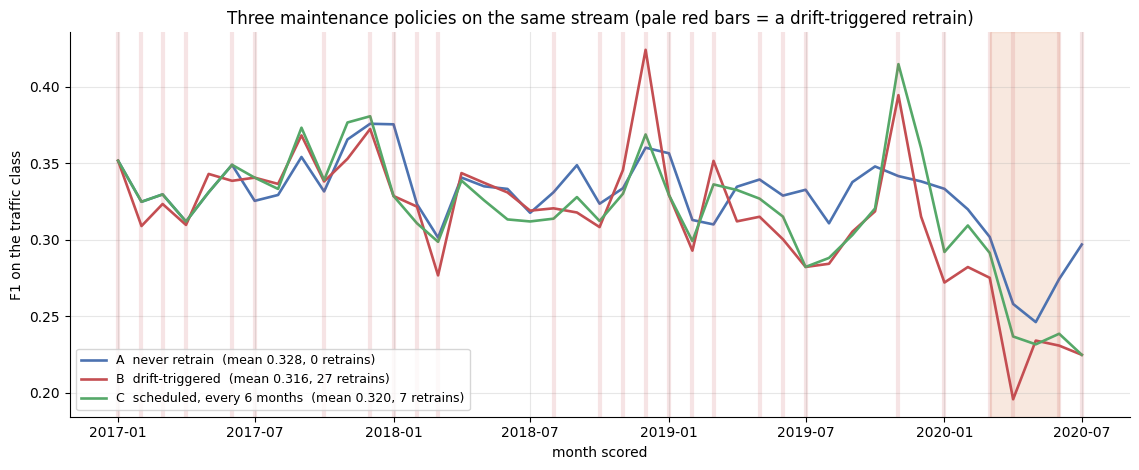

Total notebook runtime so far: 25.6 s


In [10]:
# WHAT: plot the three policies' monthly F1 on one axis, with the retrain months marked.
# WHY:  a mean hides when a policy helped and when it hurt; the lockdown months are the only
#       place where the three curves have any reason to separate.
fig, ax = plt.subplots(figsize=(11.5, 4.8))
months_x = pd.PeriodIndex(drift["period"], freq="M").to_timestamp()
colors = {"A  never retrain": "#4C72B0", "B  drift-triggered": "#C44E52",
          "C  scheduled, every 6 months": "#55A868"}
for name, (scores, retrains, when) in policies.items():
    ax.plot(months_x, scores, lw=1.9, color=colors[name],
            label=f"{name}  (mean {scores.mean():.3f}, {retrains} retrains)")
for m in b_when:
    ax.axvline(pd.Period(m, "M").to_timestamp(), color="#C44E52", alpha=0.15, lw=3)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-06-01"), color="#DD8452", alpha=0.18)
ax.set_ylabel("F1 on the traffic class")
ax.set_xlabel("month scored")
ax.set_title("Three maintenance policies on the same stream (pale red bars = a drift-triggered retrain)")
ax.legend(loc="lower left", fontsize=9)
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Total notebook runtime so far: {time.perf_counter() - NOTEBOOK_START:.1f} s")

## ⚠️ Where this breaks

**One stream, one feature, one task — this is not a general result.** Everything above is measured on 911 dispatch records in one American county, with a target derived from the record's own `title` field, using hour-of-day as the monitored covariate. Change the domain and any of these numbers can invert. The claim that survives is structural: *a p-value threshold is sensitive to window size, PSI is sensitive to binning, and neither is a measurement of harm.* The specific alarm rates are not portable.

**The retraining comparison is one run, not an experiment.** Three policies, one random seed, one metric, no confidence intervals — and the differences between the policies are small next to the month-to-month variation you can see in the chart. Do not quote "never retraining won" as a finding. The honest reading is weaker and more useful: **the drift-triggered policy paid for several times as many retrains as the calendar and did not buy a better model on this stream**, which is exactly the kind of result the Window Dilemma paper says the field has not been checking for.

**Labels are instant here and are not in production.** We score F1 for April 2020 in April 2020 because the label is inside the same row. In credit, insurance, health and churn, labels arrive weeks or months late — which is precisely why teams monitor covariates in the first place. Part 5's conclusion ("watch the label mix") is easy to state and often impossible to implement; the realistic version is to watch a *proxy* for the label and to be explicit that it is a proxy.

**Our windows are non-overlapping and calendar-aligned, which is a choice.** Months are unequal in length, they align with seasonality, and nothing about a 30-day boundary is natural to emergency dispatch. Sliding windows with overlap, adaptive windows (ADWIN-style), and event-aligned windows would all give different alarm sets from the same stream. That freedom is the dilemma.

**Multiple testing is ignored throughout.** We tested one feature. A real monitor tests dozens, every day, at `p < 0.05` — so it alarms somewhere almost every day by construction, before any drift exists. Nothing in the standard runbook corrects for that.

**And the reference window is doing invisible work.** "All of 2016" is 142,360 calls in the full file (5,364 in the bundled sample), chosen because Course 05 chose it. A different reference year, or a reference built from a rolling baseline, changes the effect sizes in Part 2 and every verdict downstream of them.

## ✅ Summary

**What you actually did** (every number above was computed when this notebook ran):

- Established a verified drift event in a real 4½-year stream, from the data rather than from a story
- Ran the KS test lesson 04 taught you on 43 real monthly windows and counted how often it fires
- Changed the window length, then the reference window, and measured how much of the verdict was the windowing rather than the world
- Watched a p-value travel across its alarm threshold on an ordinary month purely because the window changed size, while the effect size sat still
- Made KS and PSI, with their standard thresholds, disagree about the same month on the same feature
- Correlated both covariate signals and the label shift against measured model degradation
- Ran three maintenance policies head to head and reported the retrain counts alongside the F1

**One more thing this notebook did to itself.** Running it on the full file and on the bundled 25,000-row sample gives 60% alarms and 0% alarms on the same county, the same years and the same lockdown. The lesson did not need a second dataset to prove its point; it only needed to be handed fewer rows.

**The one sentence to keep:** a drift alarm is a statement about your windowing, your binning and your sample size before it is a statement about the world — so monitor an effect size, tie every alarm to a decision, and make the calendar the baseline your detector has to beat.

**Where this goes next.** Lesson 07 (A/B testing and canary deployment) is where you learn to answer "did this change help" with enough statistical care to survive review; the same discipline applied to a monitoring threshold is what turns a detector from decoration into a control. Rabanser, Günnemann and Lipton's *Failing Loudly* (reference 3) is the right next read: it evaluates shift detectors against each other rather than assuming one.

## 📚 References

Each entry below was checked against its arXiv abstract page while this notebook was written.

1. Gower-Winter, B., Groen, M., & Krempl, G. (2026). *The Window Dilemma: Why Concept Drift Detection is Ill-Posed*. [arXiv:2602.06456](https://arxiv.org/abs/2602.06456) — the source of both quotations in the introduction, and of the comparison run in Part 6.
2. Lu, J., Liu, A., Dong, F., Gu, F., Gama, J., & Zhang, G. (2020). *Learning under Concept Drift: A Review*. [arXiv:2004.05785](https://arxiv.org/abs/2004.05785) — the standard survey; organises the field into detection, understanding and adaptation, and lists the benchmark datasets the 2026 critique is aimed at.
3. Rabanser, S., Günnemann, S., & Lipton, Z. C. (2019). *Failing Loudly: An Empirical Study of Methods for Detecting Dataset Shift*. NeurIPS 2019. [arXiv:1810.11953](https://arxiv.org/abs/1810.11953) — evaluates shift detectors head to head; finds two-sample testing on a learned low-dimensional representation works best, which is the upgrade path from the univariate tests used here.
4. Angelopoulos, A. N., & Bates, S. (2022). *A Gentle Introduction to Conformal Prediction and Distribution-Free Uncertainty Quantification*. [arXiv:2107.07511](https://arxiv.org/abs/2107.07511) — the complementary approach: instead of detecting that the world moved, ship predictions that carry a coverage guarantee and widen when the input is unfamiliar.